In [4]:
import ale_py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.callbacks import BaseCallback
gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [5]:
class ProgressCallback(BaseCallback):
    def __init__(self, print_every=50_000):
        super().__init__()
        self.print_every = print_every
        self.episode_rewards = []
        self.current_reward = 0
 
    def _on_step(self):
        self.current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self.current_reward)
            self.current_reward = 0
 
        if self.num_timesteps % self.print_every == 0 and self.episode_rewards:
            recent = self.episode_rewards[-20:]
            print(f"Steps: {self.num_timesteps:>8,} | "
                  f"Episodes: {len(self.episode_rewards):>4} | "
                  f"Avg score (last 20): {np.mean(recent):>7.1f} | "
                  f"Max score: {max(self.episode_rewards):>6.0f} | "
                  f"Epsilon: {self.model.exploration_rate:.3f}")
        return True

In [6]:
env = make_atari_env("ALE/MsPacman-v5", n_envs=1, seed=42)
env = VecFrameStack(env, n_stack=4)
print("Observation shape:", env.observation_space.shape)  # (84, 84, 4)

Observation shape: (84, 84, 4)


In [7]:
model = DQN(
    "CnnPolicy",
    env,
    buffer_size=100_000,       # store last 100k experiences
    learning_starts=10_000,    # random actions for first 10k steps
    exploration_fraction=0.1,  # epsilon decays over first 10% of training
    exploration_final_eps=0.01,
    verbose=0,
)
print(model.policy)

CnnPolicy(
  (q_net): QNetwork(
    (features_extractor): NatureCNN(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (5): ReLU()
        (6): Flatten(start_dim=1, end_dim=-1)
      )
      (linear): Sequential(
        (0): Linear(in_features=3136, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (q_net): Sequential(
      (0): Linear(in_features=512, out_features=9, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): NatureCNN(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (5): ReLU()
        (6): Flatten(start_dim=1, end_di

In [2]:
import torch
print(torch.__version__)        # should end in +cu124
print(torch.cuda.is_available()) # True

2.6.0+cu124
True


In [8]:
TOTAL_STEPS = 100_000
 
callback = ProgressCallback(print_every=50_000)
model.learn(total_timesteps=TOTAL_STEPS, callback=callback)
model.save("mspacman_dqn_1M")
print("Model saved!")

Steps:   50,000 | Episodes:  990 | Avg score (last 20):    22.7 | Max score:     87 | Epsilon: 0.010
Steps:  100,000 | Episodes: 1912 | Avg score (last 20):    22.0 | Max score:     87 | Epsilon: 0.010
Model saved!


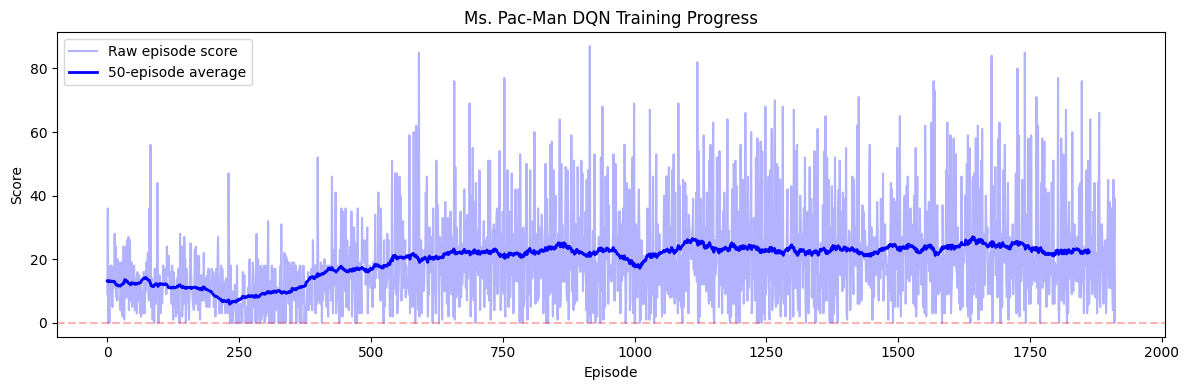

In [9]:
rewards = callback.episode_rewards
window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
 
plt.figure(figsize=(12, 4))
plt.plot(rewards, alpha=0.3, color='blue', label='Raw episode score')
plt.plot(smoothed, color='blue', linewidth=2, label=f'{window}-episode average')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.xlabel("Episode")
plt.ylabel("Score")
plt.title("Ms. Pac-Man DQN Training Progress")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
model = DQN.load("mspacman_dqn_1M")
 
test_env = make_atari_env("ALE/MsPacman-v5", n_envs=1, seed=99)
test_env = VecFrameStack(test_env, n_stack=4)
 
scores = []
for episode in range(10):
    obs = test_env.reset()
    total_reward = 0
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)  # epsilon=0
        obs, reward, done, info = test_env.step(action)
        total_reward += reward[0]
    scores.append(total_reward)
    print(f"Episode {episode+1}: score = {total_reward:.0f}")
 
print(f"\nAverage score: {np.mean(scores):.1f}")
print(f"Best score:    {max(scores):.1f}")
test_env.close()

Episode 1: score = 22
Episode 2: score = 12
Episode 3: score = 22
Episode 4: score = 64
Episode 5: score = 3
Episode 6: score = 8
Episode 7: score = 54
Episode 8: score = 17
Episode 9: score = 23
Episode 10: score = 25

Average score: 25.0
Best score:    64.0
